In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [ ]:
data = pd.read_csv("/content/fake reviews dataset.csv", engine='python', on_bad_lines='skip')
data.head()

,category,rating,label,text_
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfor..."
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I..."
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it i..."
4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the s...


In [ ]:
print(data.columns)

Index(['category', 'rating', 'label', 'text_'], dtype='object')


In [ ]:
data.shape

(20383, 4)

In [ ]:
data.isnull()

,category,rating,label,text_
0,False,False,False,False
1,False,False,False,False
2,False,False,False,False
3,False,False,False,False
4,False,False,False,False
...,...,...,...,...
20378,False,False,False,False
20379,False,False,False,False
20380,False,False,False,False
20381,False,False,False,False


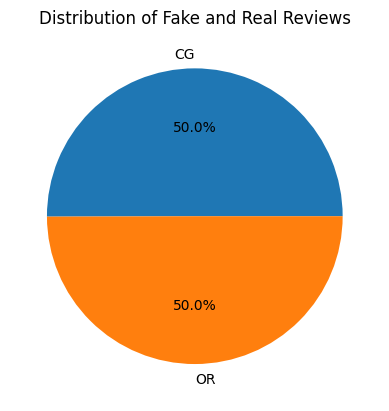

In [ ]:
counts = data['label'].value_counts()
plt.figure()
plt.pie(counts.values, labels=counts.index, autopct='%1.1f%%')
plt.title("Distribution of Fake and Real Reviews")
plt.show()


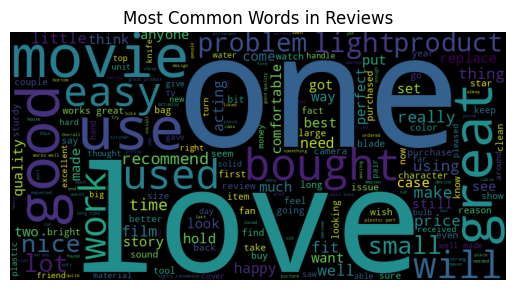

In [ ]:
from wordcloud import WordCloud

text = " ".join(data['text_'])

wordcloud = WordCloud(width=800, height=400).generate(text)

plt.figure()
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Most Common Words in Reviews")
plt.show()

In [ ]:
X = data['text_']
y = data['label']

NameError: name 'data' is not defined

In [ ]:
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(X)

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.900210213923581


In [ ]:
review = ["This product is amazing and works perfectly"]

review_vector = vectorizer.transform(review)

prediction = model.predict(review_vector)

print("Prediction:", prediction)

Prediction: ['CG']


In [ ]:
!pip install streamlit

In [ ]:
import pickle

pickle.dump(model, open("fake_review_model.pkl", "wb"))
pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))